# KTP Associate Pre-Interview Data Analysis Exercise

## Question 5: What additional insights can be obtained through modelling?

This notebook uses simple predictive models to test whether modelling adds meaningful insight beyond descriptive plots alone. The aim is not to build a final validated model, but to show which modelling strategies are informative for a small accelerated-stability dataset.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cols = ['start_date', 'pull_date', 'set_down_day', 'exposure_days', 'oven', 'temp_c', 'rh', 'analyst', 'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2', 'imp123_s1', 'imp123_s2']
lot_a_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.185, 8.119, 0.288, 0.282, 0.074, 0.074], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 11.184, 10.702, 0.246, 0.215, 0.134, 0.136], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.1, 12.238, 0.222, 0.222, 0.191, 0.189], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.518, 11.095, 0.651, 0.673, 0.167, 0.171], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.813, 11.294, 0.527, 0.541, 0.176, 0.176], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.72, 11.687, 0.314, 0.289, 0.165, 0.164], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.286, 8.409, 0.51, 0.472, 0.125, 0.126], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.519, 10.643, 0.527, 0.564, 0.186, 0.184], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.34, 12.46, 0.184, 0.178, 0.198, 0.2], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.533, 12.545, 0.165, 0.165, 0.207, 0.211], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 11.912, 12.063, 0.269, 0.273, 0.194, 0.193], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 12.172, 12.178, 0.179, 0.165, 0.25, 0.246], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.281, 12.215, 0.282, 0.279, 0.297, 0.295], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.946, 11.323, 0.535, 0.544, 0.474, 0.478], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.197, 11.597, 0.573, 0.451, 0.38, 0.39], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.951, 11.909, 0.379, 0.384, 0.615, 0.621], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.039, 12.41, 0.136, 0.132, 0.386, 0.382], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.006, 12.464, 0.223, 0.211, 0.506, 0.512], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 12.15, 11.877, 0.302, 0.289, 0.748, 0.746], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.79, 12.808, 0, 0, 0.082, 0.068]]
lot_b_rows = [['2025-12-18', '2026-01-08', 0, 21, 'Oven 2', 70, 11, 'RG', 8.439, 7.993, 0.304, 0.287, 0.113, 0.113], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 4', 65, 25, 'SS', 10.463, 10.676, 0.279, 0.213, 0.207, 0.205], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 1', 50, 64, 'SS', 12.278, 12.321, 0.253, 0.241, 0.312, 0.316], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 80, 'CM', 11.054, 11.439, 0.737, 0.7, 0.242, 0.238], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 42, 'CM', 11.504, 11.413, 0.575, 0.558, 0.287, 0.291], ['2025-12-18', '2026-01-08', 0, 21, 'Oven 3', 60, 21, 'RG', 11.653, 11.998, 0.343, 0.328, 0.271, 0.269], ['2025-12-19', '2026-01-08', 1, 20, 'Oven 2', 70, 41, 'CM', 8.677, 8.406, 0.472, 0.491, 0.174, 0.174], ['2025-12-19', '2026-01-07', 2, 19, 'Oven 4', 65, 63, 'RG', 10.33, 10.621, 0.52, 0.465, 0.25, 0.252], ['2025-12-22', '2026-01-08', 4, 17, 'Oven 1', 50, 64, 'CM', 12.171, 12.14, 0.186, 0.186, 0.305, 0.309], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 1', 50, 64, 'CM', 12.308, 12.387, 0.166, 0.17, 0.309, 0.307], ['2025-12-25', '2026-01-08', 7, 14, 'Oven 3', 60, 21, 'CM', 12.206, 11.714, 0.288, 0.296, 0.31, 0.316], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 4', 65, 25, 'RG', 11.83, 11.734, 0.19, 0.169, 0.332, 0.326], ['2026-01-01', '2026-01-08', 14, 7, 'Oven 3', 60, 42, 'SS', 12.419, 12.228, 0.291, 0.301, 0.424, 0.432], ['2026-01-02', '2026-01-08', 15, 6, 'Oven 2', 70, 79, 'CM', 10.829, 10.606, 0.583, 0.531, 0.546, 0.542], ['2026-01-02', '2026-01-07', 16, 5, 'Oven 2', 70, 11, 'RG', 11.32, 11.16, 0.607, 0.576, 0.517, 0.515], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 2', 70, 41, 'RG', 11.677, 12.051, 0.454, 0.426, 0.773, 0.771], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 3', 60, 80, 'RG', 12.307, 12.258, 0.134, 0.135, 0.482, 0.48], ['2026-01-06', '2026-01-08', 19, 2, 'Oven 4', 65, 63, 'SS', 12.137, 12.155, 0.236, 0.232, 0.658, 0.65], ['2026-01-07', '2026-01-08', 20, 1, 'Oven 2', 70, 79, 'CM', 11.733, 12.053, 0.314, 0.312, 0.888, 0.882], [None, None, 21, 0, 'n/a', 'control', 'control', 'SS', 12.493, 12.72, 0, 0, 0.143, 0.143]]
df_a = pd.DataFrame(lot_a_rows, columns=cols)
df_b = pd.DataFrame(lot_b_rows, columns=cols)
df_a['lot'] = 'A014'
df_b['lot'] = 'B025'
df = pd.concat([df_a, df_b], ignore_index=True)
for metric_name, pair_cols in {'assay':['assay_s1','assay_s2'], 'imp092':['imp092_s1','imp092_s2'], 'imp123':['imp123_s1','imp123_s2']}.items():
    df[metric_name + '_mean'] = df[pair_cols].mean(axis=1)
df['is_control'] = df['exposure_days'].eq(0)
model_df = df.loc[~df['is_control']].copy()
for col_name in ['temp_c', 'rh', 'exposure_days']:
    model_df[col_name] = pd.to_numeric(model_df[col_name], errors='coerce')
model_df['lot_code'] = model_df['lot'].map({'A014':0, 'B025':1})
model_df.head()


,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh,analyst,assay_s1,assay_s2,imp092_s1,imp092_s2,imp123_s1,imp123_s2,lot,assay_mean,imp092_mean,imp123_mean,is_control,lot_code
0,2025-12-18,2026-01-08,0,21,Oven 2,70,11,RG,8.185,8.119,0.288,0.282,0.074,0.074,A014,8.1520,0.2850,0.074,False,0
1,2025-12-18,2026-01-08,0,21,Oven 4,65,25,SS,11.184,10.702,0.246,0.215,0.134,0.136,A014,10.9430,0.2305,0.135,False,0
2,2025-12-18,2026-01-08,0,21,Oven 1,50,64,SS,12.100,12.238,0.222,0.222,0.191,0.189,A014,12.1690,0.2220,0.190,False,0
3,2025-12-18,2026-01-08,0,21,Oven 3,60,80,CM,11.518,11.095,0.651,0.673,0.167,0.171,A014,11.3065,0.6620,0.169,False,0
4,2025-12-18,2026-01-08,0,21,Oven 3,60,42,CM,11.813,11.294,0.527,0.541,0.176,0.176,A014,11.5535,0.5340,0.176,False,0


In [2]:
feature_cols = ['lot_code', 'exposure_days', 'temp_c', 'rh']
response_cols = ['assay_mean', 'imp092_mean', 'imp123_mean']
results_rows = []
prediction_frames = []
loo_cv = LeaveOneOut()
for response_name in response_cols:
    linear_model = LinearRegression()
    linear_pred = cross_val_predict(linear_model, model_df[feature_cols], model_df[response_name], cv=loo_cv)
    linear_model.fit(model_df[feature_cols], model_df[response_name])
    poly_model = Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('reg', LinearRegression())])
    poly_pred = cross_val_predict(poly_model, model_df[feature_cols], model_df[response_name], cv=loo_cv)
    poly_model.fit(model_df[feature_cols], model_df[response_name])
    results_rows.append({'response': response_name, 'linear_train_r2': round(r2_score(model_df[response_name], linear_model.predict(model_df[feature_cols])), 3), 'linear_loo_r2': round(r2_score(model_df[response_name], linear_pred), 3), 'linear_loo_mae': round(mean_absolute_error(model_df[response_name], linear_pred), 3), 'poly2_train_r2': round(r2_score(model_df[response_name], poly_model.predict(model_df[feature_cols])), 3), 'poly2_loo_r2': round(r2_score(model_df[response_name], poly_pred), 3), 'poly2_loo_mae': round(mean_absolute_error(model_df[response_name], poly_pred), 3)})
    prediction_frames.append(pd.DataFrame({'response': response_name, 'actual': model_df[response_name], 'linear_pred': linear_pred, 'poly2_pred': poly_pred}))
model_compare_df = pd.DataFrame(results_rows)
pred_df = pd.concat(prediction_frames, ignore_index=True)
model_compare_df


,response,linear_train_r2,linear_loo_r2,linear_loo_mae,poly2_train_r2,poly2_loo_r2,poly2_loo_mae
0,assay_mean,0.769,0.688,0.525,0.972,0.933,0.248
1,imp092_mean,0.427,0.218,0.113,0.781,0.531,0.087
2,imp123_mean,0.819,0.758,0.076,0.974,0.932,0.041


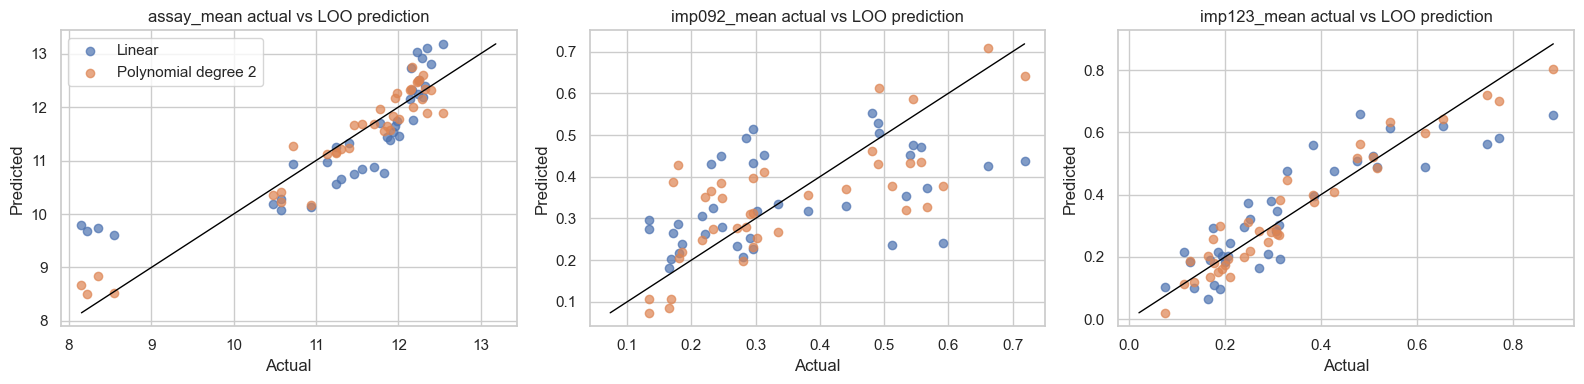

In [3]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis_obj, response_name in zip(axes, response_cols):
    plot_df = pred_df[pred_df['response'] == response_name]
    axis_obj.scatter(plot_df['actual'], plot_df['linear_pred'], label='Linear', alpha=0.7)
    axis_obj.scatter(plot_df['actual'], plot_df['poly2_pred'], label='Polynomial degree 2', alpha=0.7)
    low_val = min(plot_df['actual'].min(), plot_df['linear_pred'].min(), plot_df['poly2_pred'].min())
    high_val = max(plot_df['actual'].max(), plot_df['linear_pred'].max(), plot_df['poly2_pred'].max())
    axis_obj.plot([low_val, high_val], [low_val, high_val], color='black', linewidth=1)
    axis_obj.set_title(response_name + ' actual vs LOO prediction')
    axis_obj.set_xlabel('Actual')
    axis_obj.set_ylabel('Predicted')
axes[0].legend()
plt.tight_layout()
plt.show()


## Modelling interpretation

Two approaches are compared here: a simple linear model and a second-degree polynomial model. The linear model is useful because it is easy to interpret and shows the broad directional effects of time, temperature, humidity, and formulation. However, the polynomial model tests whether mild nonlinearity and interaction effects improve predictive performance.

For all three endpoints, the polynomial model performs better under leave-one-out validation. The biggest improvement is seen for assay and Impurity RRT 1.23, which suggests the degradation relationships are not purely linear. This is consistent with the visual analysis, especially the rapid early formation pattern seen for Impurity RRT 1.23.

The practical insight from modelling is not just prediction accuracy. It suggests that future work should consider response-surface or kinetic-style models rather than relying only on straight-line trends. In particular, the data appear rich enough to justify interaction terms between time, temperature, and humidity, even if the current dataset is too small for a high-confidence mechanistic model.

The strengths of this approach are that it is transparent, quick to implement, and useful for comparing whether extra model flexibility is justified. The limitation is that the dataset is very small, so even cross-validated gains should be interpreted cautiously. A more complex model could still overfit if taken too literally. For that reason, these models are best viewed as exploratory tools that guide the design of a more informative follow-up study.
